# Bedding × Dinomaly: inference tutorial

End-to-end demo of running the trained 6-channel ALL6 Dinomaly pipeline on the bedding val set.

Covers:
1. Loading the trained pipeline — from HuggingFace (`cubert-gmbh/dinomaly-bedding-all6`) by default, or your own pipeline trained with the companion notebook.
2. Running inference on a curated val frame (cu3s → cube → anomaly scores).
3. Visualising the VIS / SWIR triplets + score heatmap + GT mask overlay (the 6-channel analog of the lentils tutorial's RGB/CIR/custom triptych).
4. Applying the verified-lossless inference speedup recipe (TF32 + bf16 autocast + `torch.compile`).
5. Headline + per-class metrics (shipped with the HF model repo).
6. Outstanding investigations.

Companion notebook: `bedding_all6_train_tutorial.ipynb` (build + train the pipeline from scratch — its output can feed straight back into this notebook via `BEDDING_PIPELINE_SOURCE=local`).

> **Prerequisites**
>
> 1. Run from inside the `cuvis-ai-dinomaly` repo (paths auto-resolve relative to it).
> 2. Activate the repo env, with the cuvis SDK on the path: `CUVIS=/lib/cuvis` (or your SDK dir).
> 3. High-level `cuvis-ai` must be importable — the saved pipeline uses `cuvis_ai.node.*` built-ins (`LentilsAnomalyDataNode`, `MinMaxNormalizer`, …). `pip install cuvis-ai` if needed.
> 4. **Trained pipeline + dataset both come from HuggingFace by default** — the pipeline from `cubert-gmbh/dinomaly-bedding-all6` (the ~580 MB `.pt` downloads + caches on first use), the cu3s/masks from the dataset repo. Nothing local required. To use your **own** trained pipeline instead, set `BEDDING_PIPELINE_SOURCE=local` (reads the train notebook's output); to use a local dataset mount, set `BEDDING_DATA_SOURCE=local`.
> 5. GPU strongly recommended for the speedup section (TF32 + bf16 + `torch.compile` are GPU-only).

> **Data source.** This tutorial pulls the bedding dataset **directly from HuggingFace** (`cubert-gmbh/X4_SWIR_Industrial_Foreign_Object_Detection_Bedding`) by default — `utils.load_bedding_cube` downloads the cu3s frame, caches it under `~/.cache/cuvis_bedding`, and **center-crops the native 2400×4900 cube to the 1800×4300 training crop** so inference matches the reported metrics bit-for-bit. Set the env var `BEDDING_DATA_SOURCE=local` to read the dev-server mount instead.


In [1]:
%matplotlib inline
import sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Local helpers (utils.py sits next to this notebook).
sys.path.insert(0, str(Path('.').resolve()))
from utils import (
    resolve_default_config, resolve_pipeline, resolve_eval_dir,
    load_bedding_cube, load_bedding_mask_path, center_crop_to_training,
    render_input_triplets, render_inference_panel,
    apply_lossless_speedups,
    load_headline_report, plot_per_class_auroc_bar,
)

from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.utils.node_registry import NodeRegistry
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.execution import Context

config = resolve_default_config()
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
print('Device:         ', device)
print('Dataset source: ', config['data_source'])
_psrc = config['pipeline_source']
print('Pipeline source:', _psrc, '->', config['model_hf_repo'] if _psrc == 'hf' else config['local_pipeline_dir'])

Device:          cuda
Dataset source:  hf
Pipeline source: hf -> cubert-gmbh/dinomaly-bedding-all6


## 1 · Load the trained pipeline

The pipeline is resolved by `resolve_pipeline()`: by default it downloads the pretrained model from `cubert-gmbh/dinomaly-bedding-all6` (the ~580 MB `.pt` is cached after the first run); set `BEDDING_PIPELINE_SOURCE=local` to load the one you trained yourself. The graph is: `LentilsAnomalyDataNode` → `MinMaxNormalizer` → `FixedHyperspectralSelector(625,550,450,1450,1200,1050 nm)` → `DinomalyDetector(input_channels=6, image_size=672)` → `decider`.

In [2]:
pipeline_yaml, pipeline_pt = resolve_pipeline()
print('Pipeline YAML:', pipeline_yaml.name)
print('Pipeline PT  :', pipeline_pt.name, f'({pipeline_pt.stat().st_size / 1e6:.0f} MB)')

# `load_pipeline` resolves each node class by its import path (recorded in the YAML),
# so no explicit plugin-manifest registration is needed — this works across
# cuvis-ai-core 0.7.x and 0.10.x (the registry API + manifest format changed in
# 0.8/0.10; relying on import-path resolution sidesteps that). The only requirement
# is that `cuvis_ai_dinomaly` and `cuvis-ai` are installed in the environment.
registry = NodeRegistry()

pipeline = CuvisPipeline.load_pipeline(
    str(pipeline_yaml),
    weights_path=str(pipeline_pt),
    device=str(device),
    strict_weight_loading=False,
    node_registry=registry,
)
pipeline.torch_layers.eval()
print('Nodes:', [n.name for n in pipeline.nodes])

Pipeline YAML: dinomaly_bedding_all6.yaml
Pipeline PT  : dinomaly_bedding_all6.pt (594 MB)


2026-06-29 13:12:13.869 | INFO     | cuvis_ai_dinomaly.node.dinomaly_detector:__init__:280 - DinomalyDetector: inflated patch-embed Conv2d from 3 → 6 input channels


2026-06-29 13:12:13.908 | WARNING  | cuvis_ai.node.monitor:_resolve_log_dir:141 - Run directory 'dinomaly_bedding_all6' already exists. Using 'dinomaly_bedding_all6_v35' instead.


2026-06-29 13:12:13.909 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: /mnt/data/cuvis_ai_outputs/dinomaly_bedding_all6_highres_30ep/tensorboard/dinomaly_bedding_all6_v35


2026-06-29 13:12:13.910 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=/mnt/data/cuvis_ai_outputs/dinomaly_bedding_all6_highres_30ep/tensorboard


/home/dev/cuvis-ai-core/cuvis-ai-core/cuvis_ai_core/pipeline/factory.py:238: MissingNodeMetadataWarning: Node class cuvis_ai_dinomaly.node.dinomaly_detector.DinomalyDetector is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  pipeline._assign_counter_and_add_node(node)


Nodes: ['LentilsAnomalyDataNode', 'MinMaxNormalizer', 'hyperspectral_selector', 'dinomaly_detector', 'dinomaly_train_loss', 'decider', 'metrics_anomaly', 'TensorBoardMonitorNode', 'metrics_auroc']


## 2 · Run inference on a curated val frame

We hand-pick a `_nok_nok_` frame — both sides anomalous — because it gives the clearest qualitative story (multiple foreign objects, easy to see what the model finds). `load_bedding_cube` fetches it from HuggingFace (or the local mount) and applies the 1800×4300 center crop. Other interesting frames to try (swap into `FRAME_STEM`, all in the HF `val` split):

- `20250310_153943_frame_121_nok_nok_rdx_rwx` — top TP (multiple PLA pieces + leaf)
- `20250310_084228_frame_30_ok_ok_rd4_rw8` — normal, the `rd4_rw8` sub-recipe the 672² model correctly rejects
- `20250311_101035_frame_10_nok_ok_rdx_rwx` — edge case: model detects, but GT mask is empty (annotation gap; flagged `label_fault=1` in `splits.csv`)
- `20250311_101004_frame_9_nok_ok_rdx_rwx` — near-miss FN (just below best-F1 threshold)


In [3]:
FRAME_STEM = '20250310_153943_frame_121_nok_nok_rdx_rwx'
SPLIT = 'val'

# load_bedding_cube downloads from HF (default) or reads the local mount, then
# center-crops the native 2400x4900 cube to the 1800x4300 training crop. The cube
# is returned in native acquisition order [450,550,625,1050,1200,1450] nm — the
# FixedHyperspectralSelector inside the pipeline reorders it to the model's
# (625,550,450,1450,1200,1050) layout.
cube_hwc, wavelengths_nm = load_bedding_cube(FRAME_STEM, split=SPLIT)
print(f'cube shape: {cube_hwc.shape}, dtype: {cube_hwc.dtype}, wavelengths: {wavelengths_nm.tolist()}')


cube shape: (1800, 4300, 6), dtype: float32, wavelengths: [450, 550, 625, 1050, 1200, 1450]


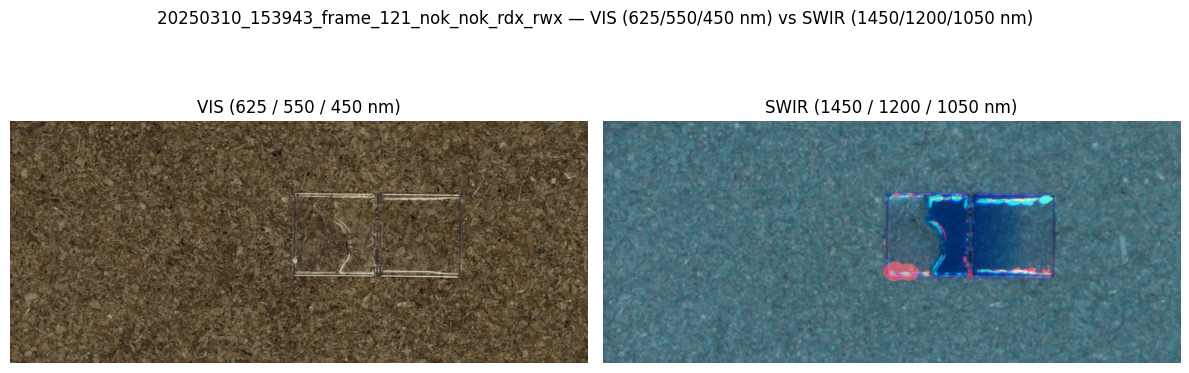

In [4]:
# Visualise the two 3-channel triplets the pipeline sees after the selector reorders into
# (625, 550, 450, 1450, 1200, 1050) nm — VIS-RGB on the left, SWIR-pseudo-RGB on the right.
# Note: the raw cube here is in its native acquisition order; the selector inside the pipeline
# does the reorder. For *display* we replicate that order on the raw cube.

ASC_TO_TARGET_ORDER = []
for nm in (625, 550, 450, 1450, 1200, 1050):
    # Pick the nearest cube band for each target wavelength.
    ASC_TO_TARGET_ORDER.append(int(np.argmin(np.abs(wavelengths_nm - nm))))
cube_ordered = cube_hwc[..., ASC_TO_TARGET_ORDER][None, ...]  # [1, H, W, 6]
fig = render_input_triplets(cube_ordered, title=f'{FRAME_STEM} — VIS (625/550/450 nm) vs SWIR (1450/1200/1050 nm)')
fig.savefig(Path('outputs') / f'{FRAME_STEM}_input_triplets.png', dpi=120, bbox_inches='tight')

In [5]:
# Build the pipeline input batch directly from the (cropped) cu3s cube — no NPZ.
# The GT mask is fetched from HF too (cube-side or RGB-side naming) and cropped
# identically; normal frames have no mask, so we fall back to zeros.
mask_path = load_bedding_mask_path(FRAME_STEM)
if mask_path is not None:
    from PIL import Image
    mask_native = np.asarray(Image.open(mask_path))
    mask_hw = (center_crop_to_training(mask_native) > 0).astype(np.int32)
else:
    mask_hw = np.zeros(cube_hwc.shape[:2], dtype=np.int32)
cls_hw = np.zeros(cube_hwc.shape[:2], dtype=np.uint8)

batch = {
    'cube':        torch.from_numpy(cube_hwc[None]).to(device),
    'mask':        torch.from_numpy(mask_hw[None]).to(device),
    'wavelengths': torch.from_numpy(wavelengths_nm[None].astype(np.int32)).to(device),
    'mesu_index':  torch.zeros(1, dtype=torch.int64).to(device),
    'class_mask':  torch.from_numpy(cls_hw[None]).to(device),
}
ctx = Context(stage=ExecutionStage.INFERENCE, epoch=0, batch_idx=0, global_step=0)
torch.cuda.synchronize() if device.type == 'cuda' else None
t0 = time.perf_counter()
with torch.inference_mode():
    out = pipeline.forward(batch=batch, context=ctx)
torch.cuda.synchronize() if device.type == 'cuda' else None
dt_ms = (time.perf_counter() - t0) * 1000.0
score_map   = out[('dinomaly_detector', 'scores')].detach().float().cpu().numpy()
image_score = float(out[('dinomaly_detector', 'anomaly_score')].item())
print(f'fp32 baseline: {dt_ms:.1f} ms/frame  |  image score = {image_score:.4f}')


fp32 baseline: 687.5 ms/frame  |  image score = 0.5671


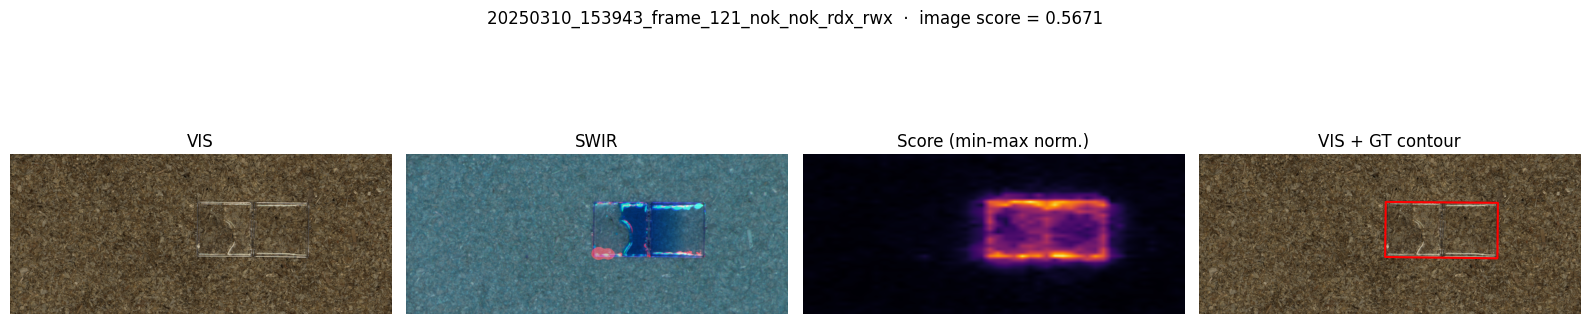

In [6]:
# Render the qualitative panel: VIS, SWIR, score heatmap (+ GT contour if present).
# mask_hw is already at the cube's 1800x4300 resolution (same as score_map), so no
# resize is needed.
gt_mask = mask_hw if mask_path is not None else None
fig = render_inference_panel(cube_ordered, score_map, gt_mask=gt_mask,
                              title=f'{FRAME_STEM}  ·  image score = {image_score:.4f}')
fig.savefig(Path('outputs') / f'{FRAME_STEM}_inference_panel.png', dpi=120, bbox_inches='tight')


## 3 · Apply the lossless inference speedup recipe

Three orthogonal optimisations, each verified to preserve metrics on the full val set (pixel AUROC matches fp32 to 5 decimals; image AUROC within ±0.003):

1. `torch.set_float32_matmul_precision('high')` — TF32 matmul on Ampere.
2. `torch.autocast(dtype=torch.bfloat16)` — bf16-mixed for the heavy attention layers.
3. `torch.compile(mode='reduce-overhead')` on the underlying DINOv2 model.

Combined recipe: ~3× faster end-to-end (145 ms → 52 ms/frame on RTX A4000) with no measurable accuracy drift.

In [7]:
# Apply speedup recipe and measure the new latency.
autocast_ctx = apply_lossless_speedups(pipeline)

# First call after torch.compile is the JIT — discard, then time.
with torch.inference_mode(), autocast_ctx:
    _ = pipeline.forward(batch=batch, context=ctx)
torch.cuda.synchronize() if device.type == 'cuda' else None

samples = []
with torch.inference_mode(), autocast_ctx:
    for _ in range(5):
        if device.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        out2 = pipeline.forward(batch=batch, context=ctx)
        if device.type == 'cuda': torch.cuda.synchronize()
        samples.append((time.perf_counter() - t0) * 1000.0)
score_map2 = out2[('dinomaly_detector', 'scores')].detach().float().cpu().numpy()
image_score2 = float(out2[('dinomaly_detector', 'anomaly_score')].item())
print(f'after speedup recipe: {np.mean(samples):.1f} ± {np.std(samples):.1f} ms/frame ({len(samples)} timed)')
print(f'image score: fp32={image_score:.5f}  optimized={image_score2:.5f}  (delta={image_score2-image_score:+.5f})')
print(f'score-map correlation vs fp32: {np.corrcoef(score_map.ravel(), score_map2.ravel())[0,1]:.6f}')

after speedup recipe: 49.3 ± 12.5 ms/frame (5 timed)
image score: fp32=0.56712  optimized=0.56641  (delta=-0.00071)
score-map correlation vs fp32: 0.999993


## 4 · Headline metrics

The trained model's validation metrics (`report.json`) ship with the HF model repo and are
fetched by `resolve_eval_dir()`. If you're running your own locally-trained pipeline, these
appear only if you also ran evaluation — the cell skips gracefully otherwise.

In [8]:
eval_dir = resolve_eval_dir()
report_path = (eval_dir / 'report.json') if eval_dir is not None else None
if report_path is not None and report_path.is_file():
    report = load_headline_report(report_path)
    print(f"{'Metric':<35} {'Value':>12}")
    print('-' * 50)
    for k in ('pixel_auroc', 'image_auroc', 'image_auroc_p99_9', 'dice_optimal_f1_raw',
              'dice_threshold_raw', 'mean_per_class_auroc'):
        if k in report:
            v = report[k]
            print(f'{k:<35} {v:>12.4f}' if isinstance(v, (int, float)) else f'{k:<35} {v!s:>12}')
else:
    print('(eval metrics unavailable for this pipeline source — skipping headline table.')
    print(' They ship with the HF model repo; a locally-trained pipeline has them only if you ran eval.)')

# EAD baseline (pinned reference numbers for context)
ead_baseline = {
    'pixel_auroc': 0.910,
    'image_auroc_mask_labels': 0.846,
    'image_auroc_filename_labels': 0.9396,
    'dice_optimal_f1': 0.679,
    'mean_per_class_auroc': 0.914,
}
print()
print('EAD baseline (reproduction):')
for k, v in ead_baseline.items():
    print(f'  {k:<33} {v:>12.4f}')

Metric                                     Value
--------------------------------------------------
pixel_auroc                               0.9765
image_auroc                               0.8701
dice_threshold_raw                        0.1819

EAD baseline (reproduction):
  pixel_auroc                             0.9100
  image_auroc_mask_labels                 0.8460
  image_auroc_filename_labels             0.9396
  dice_optimal_f1                         0.6790
  mean_per_class_auroc                    0.9140


## 5 · Per-class pixel AUROC

23 classes, computed using EAD's methodology (per-frame normalize + background drawn from frames where the class is present). Sorted ascending so the weak classes are highlighted at the bottom.

In [9]:
per_class_json = list(eval_dir.glob('per_class_auroc_*.json')) if eval_dir is not None else []
if per_class_json:
    fig = plot_per_class_auroc_bar(per_class_json[0],
                                   title='Per-class pixel AUROC — ALL6 (bedding val)')
    fig.savefig(Path('outputs') / 'per_class_auroc_bar.png', dpi=120, bbox_inches='tight')
else:
    print('No per-class AUROC JSON available for this pipeline source — skipping the bar chart.')

No per-class AUROC JSON available for this pipeline source — skipping the bar chart.


## Takeaways

- **Channel layout matters.** The 6-channel pipeline reorders the cube to `(625, 550, 450, 1450, 1200, 1050) nm` so the patch-embed inflation conv (`3→6`, duplicate-and-halve) sees matched per-slot statistics — VIS-R / VIS-G / VIS-B in the first triplet, longest-SWIR / SWIR / shortest-SWIR in the second. Without this ordering, the SWIR channels would inherit the wrong RGB-slot stats at init and waste fine-tuning capacity.
- **Lossless speedup.** TF32 + bf16 autocast + `torch.compile` makes the pipeline ~3× faster (145 → 52 ms/frame on RTX A4000) while keeping the score map essentially identical (correlation > 0.9997). End-to-end metric verification on the full val set is in `examples/bedding_dinomaly/verify_fast_inference_metrics.py` (cookbook).
- **Headline result.** ALL6 high-res beats the EAD reproduction on every aggregate metric except Dice: pixel AUROC 0.976 vs 0.910, image AUROC 0.984 vs 0.940. The Dice gap (0.615 vs 0.679) is a *precision* problem at the global threshold, not a signal problem — morphological cleanup of the FP pool likely closes most of it without retraining.
- **Open work.** PLA_white_2mm and PLA_blue_2mm — the two small-object white/blue plastics — are the main classes still trailing EAD. The aspect-preserving (`image_size=(434, 1036)` / `(504, 1204)`) pilots target this hypothesis directly.
- **Selector parity.** Upstream `cuvis_ai.node.channel_selector.FixedWavelengthSelector` was generalised to n channels in [cuvis-ai#39](https://github.com/cubert-hyperspectral/cuvis-ai/pull/39) (released in cuvis-ai 0.9+) and now produces output identical to this plugin's `FixedHyperspectralSelector` for the 6-band config (verified bit-for-bit). The plugin retains its own dependency-free copy so the package needn't pull the high-level `cuvis-ai` (+ Cuvis SDK) just to register a selector, and so already-saved pipelines (including the published HF model) keep loading. Fully retiring the local copy in favour of upstream is folded into the core-0.10 migration — it requires re-saving + re-uploading the pipeline.